In [13]:
pip install numpy==1.26.4 matplotlib==3.7.5 pandas openpyxl seaborn


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 188.0 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
#a1
import pandas as pd
import numpy as np

def load_purchase_data(file_path):
    data = pd.read_excel(file_path, sheet_name= 0)
    return data

def create_xandy(data):
    X = data[["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]].values
    Y = data["Payment (Rs)"].values
    return X,Y

def find_rank(matrix):
    return np.linalg.matrix_rank(matrix)

def find_cost_using_pinv(X,Y):
    X_pinv = np.linalg.pinv(X)
    cost = X_pinv.dot(Y)
    return cost


def main():
    file_path = "Lab Session Data.xlsx"
    data = load_purchase_data(file_path)
    X, Y = create_xandy(data)

    print("dimensionality:", X.shape[1])
    print("number of vectors:", X.shape[0])
    rank = find_rank(X)
    cost = find_cost_using_pinv(X, Y)
    print("cost of candies:", cost[0])
    print("cost of mangoes:", cost[1])
    print("cost of milk packets", cost[2])

main()    

dimensionality: 3
number of vectors: 10
cost of candies: 0.9999999999999984
cost of mangoes: 55.000000000000014
cost of milk packets 18.0


In [2]:
# a2
import pandas as pd

def label_Customers(payment_list):
    result = []
    for p in payment_list:
        if p > 200:
            result.append("rich")
        else:
            result.append("poor")
    return result

def main():
    file_path = "Lab Session Data.xlsx"
    data = pd.read_excel(file_path, sheet_name=0)
    payment = data["Payment (Rs)"].values
    labels = label_Customers(payment)
    data["Status"] = labels
    print(data[["Payment (Rs)", "Status"]])
main()


   Payment (Rs) Status
0           386   rich
1           289   rich
2           393   rich
3           110   poor
4           280   rich
5           167   poor
6           271   rich
7           274   rich
8           148   poor
9           198   poor


Mean (numpy): 1560.6634538152612
Variance (numpy): 58496.49239931613
Mean (manual): 1560.6634538152598
Variance (manual): 58496.49239931618
Avg time mean (numpy): 5.459785461425781e-06
Avg time mean (manual): 1.8143653869628905e-05
Wednesday mean: 0
April mean: 1698.9526315789474
Probability of loss: 0.4979919678714859
Profit on Wednesday: 0


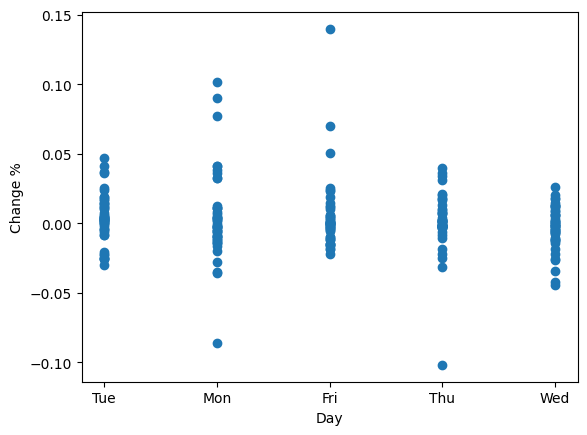

In [5]:
#a3
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

def load_irctc_data(file_path):
    data = pd.read_excel(file_path, sheet_name=1)
    return data

def mean_numpy(values):
    return np.mean(values)

def var_numpy(values):
    return np.var(values)

def mean_manual(values):
    total = 0
    for v in values:
        total += v
    return total/len(values)

def var_manual(values):
    m = mean_manual(values)
    total = 0
    for v in values:
        total += (v-m) ** 2
    return total / len(values)

def avg_time(func, values):
    total_time = 0
    for i in range(10):
        start = time.time()
        func(values)
        end = time.time()
        total_time += (end - start)
    return total_time / 10

def wednesday_mean(data):
    wed_data = data[data["Day"].str.strip().str.lower() == "wednesday"]
    if len(wed_data) == 0:
        return 0
    return mean_manual(wed_data["Price"].values)


def april_mean(data):
    apr_data = data[data["Month"].str.strip().str.lower() == "apr"]
    if len(apr_data) == 0:
        return 0
    return mean_manual(apr_data["Price"].values)


def loss_probability(chg):
    loss_days = list(filter(lambda x: x < 0, chg))
    return len(loss_days) / len(chg)

def profit_on_wednesday(data):   # SAFE VERSION
    wed = data[data["Day"].str.strip().str.lower() == "wednesday"]
    if len(wed) == 0:
        return 0
    profit = wed[wed["Chg%"] > 0]
    return len(profit) / len(wed)


def scatter_plot(data):
    plt.scatter(data["Day"], data["Chg%"])
    plt.xlabel("Day")
    plt.ylabel("Change %")
    plt.show()

def main():
    file_path = "Lab Session Data.xlsx"
    data = load_irctc_data(file_path)

    price = data["Price"].values
    chg = data["Chg%"].values

    print("Mean (numpy):", mean_numpy(price))
    print("Variance (numpy):", var_numpy(price))

    print("Mean (manual):", mean_manual(price))
    print("Variance (manual):", var_manual(price))

    print("Avg time mean (numpy):", avg_time(mean_numpy, price))
    print("Avg time mean (manual):", avg_time(mean_manual, price))

    print("Wednesday mean:", wednesday_mean(data))
    print("April mean:", april_mean(data))

    print("Probability of loss:", loss_probability(chg))
    print("Profit on Wednesday:", profit_on_wednesday(data))

    scatter_plot(data)

main()


In [7]:
# A4
import pandas as pd
import numpy as np

def load_thyroid_data(file_path):
    return pd.read_excel(file_path, sheet_name=2)

def show_basic_info(data):
    print("Shape:", data.shape)
    print("\nColumns:")
    print(list(data.columns))
    print("\nData types:")
    print(data.dtypes)

def missing_values(data):
    print("\nMissing values per column:")
    print(data.isna().sum())

def numeric_stats(data):
    num_cols = data.select_dtypes(include=[np.number]).columns
    print("\nNumeric columns mean and variance:")
    for col in num_cols:
        mean_val = data[col].mean()
        var_val = data[col].var()
        print(col, "-> Mean:", mean_val, "Variance:", var_val)

def data_ranges(data):
    num_cols = data.select_dtypes(include=[np.number]).columns
    print("\nRanges of numeric columns:")
    for col in num_cols:
        print(col, "-> Min:", data[col].min(), "Max:", data[col].max())

def detect_outliers_iqr(data):
    num_cols = data.select_dtypes(include=[np.number]).columns
    print("\nOutlier count using IQR method:")
    for col in num_cols:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = data[(data[col] < lower) | (data[col] > upper)]
        print(col, "->", len(outliers))

def categorical_encoding_suggestion(data):
    cat_cols = data.select_dtypes(include=["object"]).columns
    print("\nEncoding suggestion for categorical columns:")
    for col in cat_cols:
        unique_vals = data[col].nunique()
        if unique_vals <= 2:
            print(col, "-> Binary / Label Encoding")
        else:
            print(col, "-> One-Hot Encoding")


def main():
    file_path = "Lab Session Data.xlsx"
    data = load_thyroid_data(file_path)

    show_basic_info(data)
    missing_values(data)
    data_ranges(data)
    numeric_stats(data)
    detect_outliers_iqr(data)
    categorical_encoding_suggestion(data)

main()


Shape: (9172, 31)

Columns:
['Record ID', 'age', 'sex', 'on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH', 'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U measured', 'T4U', 'FTI measured', 'FTI', 'TBG measured', 'TBG', 'referral source', 'Condition']

Data types:
Record ID                     int64
age                           int64
sex                          object
on thyroxine                 object
query on thyroxine           object
on antithyroid medication    object
sick                         object
pregnant                     object
thyroid surgery              object
I131 treatment               object
query hypothyroid            object
query hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object


In [ ]:
# A5
import pandas as pd
import numpy as np

def load_thyroid_data(file_path):
    return pd.read_excel(file_path, sheet_name=2)

def get_binary_attributes(data):
    binary_cols = []
    for col in data.columns:
        unique_vals = data[col].dropna().unique()
        if set(unique_vals).issubset({0, 1}):
            binary_cols.append(col)
    return binary_cols

def compute_frequencies(v1, v2):
    f11 = f10 = f01 = f00 = 0
    for i in range(len(v1)):
        if v1[i] == 1 and v2[i] == 1:
            f11 += 1
        elif v1[i] == 1 and v2[i] == 0:
            f10 += 1
        elif v1[i] == 0 and v2[i] == 1:
            f01 += 1
        elif v1[i] == 0 and v2[i] == 0:
            f00 += 1
    return f11, f10, f01, f00

def jaccard_coefficient(f11, f10, f01):
    denom = f11 + f10 + f01
    if denom == 0:
        return 0
    return f11 / denom

def simple_matching_coefficient(f11, f10, f01, f00):
    total = f11 + f10 + f01 + f00
    if total == 0:
        return 0
    return (f11 + f00) / total

def main():
    file_path = "Lab Session Data.xlsx"
    data = load_thyroid_data(file_path)
    binary_cols = get_binary_attributes(data)
    v1 = data.loc[0, binary_cols].values
    v2 = data.loc[1, binary_cols].values
    f11, f10, f01, f00 = compute_frequencies(v1, v2)
    jc = jaccard_coefficient(f11, f10, f01)
    smc = simple_matching_coefficient(f11, f10, f01, f00)
    print("f11:", f11)
    print("f10:", f10)
    print("f01:", f01)
    print("f00:", f00)
    print("Jaccard Coefficient:", jc)
    print("Simple Matching Coefficient:", smc)

main()


f11: 0
f10: 0
f01: 0
f00: 0
Jaccard Coefficient: 0
Simple Matching Coefficient: 0


In [ ]:
#A6
import pandas as pd
import numpy as np

def load_thyroid_data(file_path):
    return pd.read_excel(file_path, sheet_name=2)

def get_numeric_data(data):
    return data.select_dtypes(include=[np.number])

def cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    
    if norm_v1 == 0 or norm_v2 == 0:
        return 0
    return dot_product / (norm_v1 * norm_v2)

def main():
    file_path = "Lab Session Data.xlsx"
    data = load_thyroid_data(file_path)
    numeric_data = get_numeric_data(data)
    v1 = numeric_data.iloc[0].values
    v2 = numeric_data.iloc[1].values
    cos_sim = cosine_similarity(v1, v2)
    print("Cosine Similarity:", cos_sim)

main()


Cosine Similarity: 0.9999999999999997


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


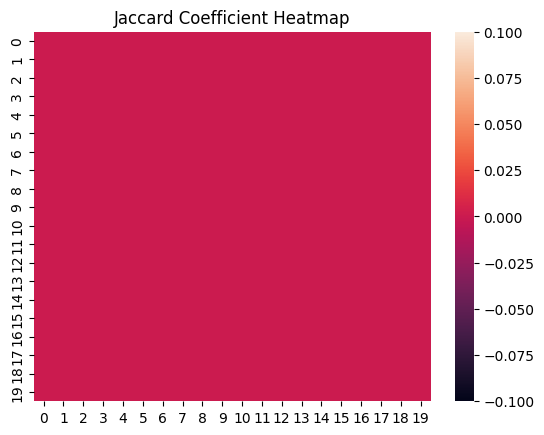

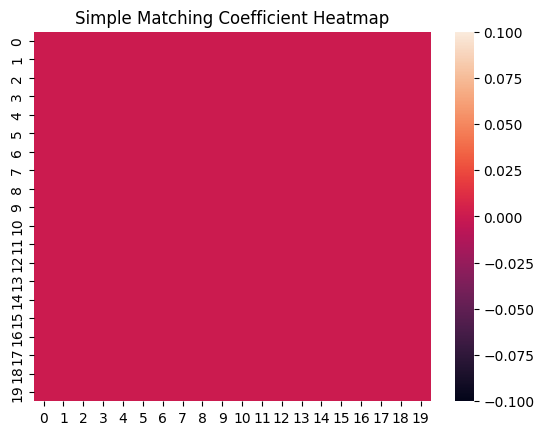

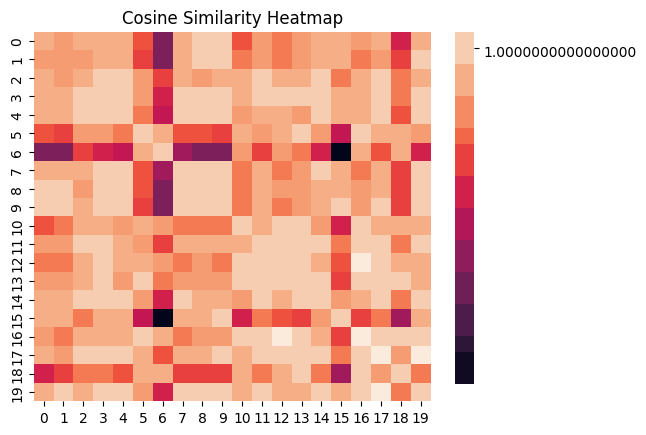

In [ ]:
# A7
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def load_thyroid_data(file_path):
    return pd.read_excel(file_path, sheet_name=2)

def get_binary_columns(data):
    cols = []
    for c in data.columns:
        vals = data[c].dropna().unique()
        if set(vals).issubset({0, 1}):
            cols.append(c)
    return cols

def compute_frequencies(v1, v2):
    f11 = f10 = f01 = f00 = 0
    for i in range(len(v1)):
        if v1[i] == 1 and v2[i] == 1:
            f11 += 1
        elif v1[i] == 1 and v2[i] == 0:
            f10 += 1
        elif v1[i] == 0 and v2[i] == 1:
            f01 += 1
        else:
            f00 += 1
    return f11, f10, f01, f00

def jaccard(f11, f10, f01):
    denom = f11 + f10 + f01
    if denom == 0:
        return 0
    return f11 / denom

def smc(f11, f10, f01, f00):
    total = f11 + f10 + f01 + f00
    if total == 0:
        return 0
    return (f11 + f00) / total

def cosine_similarity(v1, v2):
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0
    return np.dot(v1, v2) / (n1 * n2)

def main():
    file_path = "Lab Session Data.xlsx"
    data = load_thyroid_data(file_path)
    data20 = data.iloc[:20]

    binary_cols = get_binary_columns(data20)
    num_data = data20.select_dtypes(include=[np.number])

    n = len(data20)
    jc_mat = np.zeros((n, n))
    smc_mat = np.zeros((n, n))
    cos_mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if len(binary_cols) > 0:
                v1b = data20.loc[i, binary_cols].values
                v2b = data20.loc[j, binary_cols].values
                f11, f10, f01, f00 = compute_frequencies(v1b, v2b)
                jc_mat[i, j] = jaccard(f11, f10, f01)
                smc_mat[i, j] = smc(f11, f10, f01, f00)
            else:
                jc_mat[i, j] = 0
                smc_mat[i, j] = 0

            v1n = num_data.iloc[i].values
            v2n = num_data.iloc[j].values
            cos_mat[i, j] = cosine_similarity(v1n, v2n)

    # Heatmaps
    sns.heatmap(jc_mat, annot=False)
    plt.title("Jaccard Coefficient Heatmap")
    plt.show()

    sns.heatmap(smc_mat, annot=False)
    plt.title("Simple Matching Coefficient Heatmap")
    plt.show()
    sns.heatmap(cos_mat, annot=False)
    plt.title("Cosine Similarity Heatmap")
    plt.show()

main()


In [ ]:
import pandas as pd
import numpy as np

def load_thyroid_data(file_path):
    return pd.read_excel(file_path, sheet_name=2)

def has_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).any()

def impute_data(data):
    for col in data.columns:
        if data[col].isna().sum() == 0:
            continue

        if data[col].dtype != "object":
            if has_outliers(data[col].dropna()):
                median_val = data[col].median()
                data[col].fillna(median_val, inplace=True)
            else:
                mean_val = data[col].mean()
                data[col].fillna(mean_val, inplace=True)

        else:
            mode_val = data[col].mode()[0]
            data[col].fillna(mode_val, inplace=True)

    return data


def main():
    file_path = "Lab Session Data.xlsx"
    data = load_thyroid_data(file_path)

    print("Missing values before imputation:")
    print(data.isna().sum())

    data = impute_data(data)

    print("\nMissing values after imputation:")
    print(data.isna().sum())

main()


Missing values before imputation:
Record ID                    0
age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
TBG                          0
referral source              0
Condition                    0
dtype

In [ ]:
import pandas as pd
import numpy as np


def load_thyroid_data(file_path):
    return pd.read_excel(file_path, sheet_name=2)

def min_max_normalize(data):
    norm_data = data.copy()
    num_cols = norm_data.select_dtypes(include=[np.number]).columns

    for col in num_cols:
        min_val = norm_data[col].min()
        max_val = norm_data[col].max()

        if max_val - min_val != 0:
            norm_data[col] = (norm_data[col] - min_val) / (max_val - min_val)
        else:
            norm_data[col] = 0

    return norm_data


def main():
    file_path = "Lab Session Data.xlsx"
    data = load_thyroid_data(file_path)

    print("Before normalization:")
    print(data.describe())

    norm_data = min_max_normalize(data)

    print("\nAfter normalization:")
    print(norm_data.describe())

main()


Before normalization:
          Record ID           age
count  9.172000e+03   9172.000000
mean   8.529473e+08     73.555822
std    7.581969e+06   1183.976718
min    8.408010e+08      1.000000
25%    8.504090e+08     37.000000
50%    8.510040e+08     55.000000
75%    8.607110e+08     68.000000
max    8.701190e+08  65526.000000

After normalization:
         Record ID          age
count  9172.000000  9172.000000
mean      0.414296     0.001107
std       0.258611     0.018069
min       0.000000     0.000000
25%       0.327716     0.000549
50%       0.348012     0.000824
75%       0.679105     0.001023
max       1.000000     1.000000
